# Three-Model Comparison on LunarLander-v3

Based on: *Dueling Network Architectures for Deep Reinforcement Learning* (Wang et al., 2016)

## Models Compared

| # | Model | Exploration | Key Innovation |
|---|-------|-------------|----------------|
| 1 | **Dueling DDQN** | ε-greedy | Value + Advantage streams (Wang et al. 2016) |
| 2 | **Dueling + NoisyNet** | Learned σ | NoisyLinear replaces ε-greedy (Fortunato et al. 2017) |
| 3 | **Dueling + NoisyNet + ASN** | Learned σ (asymmetric) | **Asymmetric Stream Noise + Running Advantage Normalization** |

## Model 3 Innovation — Asymmetric Stream Noise (ASN)

**Core idea**: In standard NoisyNet-Dueling, both the Value stream V(s) and Advantage stream A(s,a)  
are initialised with identical σ. But they have fundamentally different jobs:

- **V(s)** estimates a *scalar* state value — it benefits from *lower* noise so it stabilises quickly
- **A(s,a)** discriminates between actions — it benefits from *higher* noise to keep exploring action rankings

ASN enforces this asymmetry explicitly:
1. **σ_value_init < σ_advantage_init** — Value stream starts with less noise (faster convergence)
2. **Running z-score normalisation on advantage outputs** before combining with V — stabilises training  
   in LunarLander where rewards range wildly (-300 to +300)
3. **σ annealing schedule on V only** — Value noise decays over time while Advantage noise is free to grow

This draws on PopArt normalisation (van Hasselt et al. 2016) but applies it asymmetrically to the  
dueling streams rather than to the full output — the mechanism is novel to this implementation.

## Environment: LunarLander-v3
- **State**: 8-dimensional (position, velocity, angle, contact sensors)
- **Actions**: 4 discrete (do nothing, left engine, main engine, right engine)
- **Reward**: +200 for landing, -100 for crash, shaped reward for approach
- **Solved**: mean score ≥ 200 over 100 episodes


## 1. Imports & Setup

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import numpy as np
import copy
import math
import os
import time
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import deque

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
os.makedirs('./lunar_data', exist_ok=True)

Device: cuda


In [8]:
ENV_NAME = 'LunarLander-v3'
env = gym.make(ENV_NAME)
N_STATE  = int(np.prod(env.observation_space.shape))
N_ACTION = env.action_space.n

print(f'Environment : {ENV_NAME}')
print(f'State dims  : {N_STATE}')
print(f'Actions     : {N_ACTION}')

# Shared hyperparameters — identical for all three models
GAMMA          = 0.99
LR             = 5e-4
BATCH_SIZE     = 64
BUFFER_SIZE    = 100_000
WARMUP         = 5_000
TARGET_SYNC    = 20       # episodes between target net sync
UPDATE_EVERY   = 4        # env steps between gradient updates
N_EPISODES     = 1_500
EVAL_EPISODES  = 100
LOG_EVERY      = 100

# ε-greedy schedule (Model 1 only)
EPS_START = 1.0
EPS_END   = 0.01
EPS_DECAY = 600          # episodes to decay over

# NoisyNet (Models 2 & 3)
SIGMA_INIT = 0.5         # symmetric init for Model 2

# ASN (Model 3 only)
ASN_SIGMA_VALUE = 0.2    # lower noise for value stream
ASN_SIGMA_ADV   = 0.7    # higher noise for advantage stream
ASN_NORM_MOMENTUM = 0.005  # running stats momentum
ASN_VALUE_ANNEAL  = 0.9998  # per-update decay on value stream sigma

print('\nHyperparameters set.')

Environment : LunarLander-v3
State dims  : 8
Actions     : 4

Hyperparameters set.


## 2. Shared Utilities

In [9]:
class ReplayBuffer:
    """
    Rank-based prioritized experience replay.
    Shared across all three models — zero differences.
    """
    def __init__(self, size, alpha=0.7, beta=0.5):
        self.size       = size
        self.buff       = []
        self.priorities = []
        self.alpha      = alpha
        self.beta       = beta
        self.position   = 0

    def add(self, obs, act, reward, next_obs, done):
        max_prio   = max(self.priorities) if self.buff else 1.0
        transition = [obs, act, reward, next_obs, done]
        if len(self.buff) < self.size:
            self.buff.append(transition)
            self.priorities.append(max_prio)
        else:
            self.buff[self.position]       = transition
            self.priorities[self.position] = max_prio
        self.position = (self.position + 1) % self.size

    def sample(self, n):
        n = min(n, len(self.buff))
        sorted_idx = np.argsort(self.priorities)[::-1]
        ranks      = np.arange(1, len(self.buff) + 1)
        probs      = (1.0 / ranks) ** self.alpha
        probs     /= probs.sum()
        s_ranks    = np.random.choice(len(self.buff), n, p=probs, replace=False)
        indices    = sorted_idx[s_ranks]
        weights    = (len(self.buff) * probs[s_ranks]) ** (-self.beta)
        weights   /= weights.max()
        weights    = torch.FloatTensor(weights).to(device)
        batch      = [self.buff[i] for i in indices]
        obs      = torch.FloatTensor(np.array([e[0] for e in batch])).to(device)
        act      = torch.LongTensor([e[1] for e in batch]).to(device)
        rew      = torch.FloatTensor([e[2] for e in batch]).to(device)
        nobs     = torch.FloatTensor(np.array([e[3] for e in batch])).to(device)
        done     = torch.FloatTensor([e[4] for e in batch]).to(device)
        return obs, act, rew, nobs, done, indices, weights

    def update_priorities(self, indices, td_errors):
        for i, e in zip(indices, td_errors):
            self.priorities[i] = abs(float(e)) + 1e-5

    def __len__(self):
        return len(self.buff)

In [10]:
def evaluate_policy(policy, n_eval=100, label=''):
    """Run n_eval greedy episodes. Returns list of total rewards."""
    scores = []
    eval_env = gym.make(ENV_NAME)
    for _ in range(n_eval):
        obs, _ = eval_env.reset()
        total  = 0.0
        while True:
            act = policy.greedy_action(obs)
            obs, r, term, trunc, _ = eval_env.step(act)
            total += r
            if term or trunc:
                break
        scores.append(total)
    eval_env.close()
    mean_s = np.mean(scores)
    std_s  = np.std(scores)
    print(f'  [{label}] eval mean={mean_s:.1f}  std={std_s:.1f}  '
          f'min={min(scores):.0f}  max={max(scores):.0f}')
    return scores

## 3. Model 1 — Original Dueling DDQN (ε-greedy)

Standard dueling architecture as in Wang et al. (2016).  
Q(s,a) = V(s) + A(s,a) − mean(A(s,·))  with ε-greedy exploration.

In [11]:
class DuelingQNet(nn.Module):
    """Original Dueling Q-Network (Wang et al. 2016)."""
    def __init__(self, n_state, n_action):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(n_state, 256), nn.ReLU(),
            nn.Linear(256, 128),     nn.ReLU()
        )
        self.value_stream = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
        self.adv_stream = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, n_action)
        )

    def forward(self, x):
        f   = self.backbone(x)
        V   = self.value_stream(f)                          # (B, 1)
        A   = self.adv_stream(f)                            # (B, n_action)
        # Equation 9 from Wang et al.
        return V + (A - A.mean(dim=1, keepdim=True))


class DuelingAgent:
    """Model 1: Dueling DDQN + prioritized replay + ε-greedy."""
    def __init__(self):
        self.q_net      = DuelingQNet(N_STATE, N_ACTION).to(device)
        self.target_net = copy.deepcopy(self.q_net)
        self.target_net.eval()
        self.optimizer  = torch.optim.Adam(self.q_net.parameters(), lr=LR)
        self.buffer     = ReplayBuffer(BUFFER_SIZE)
        self.eps        = EPS_START
        self.sync_ctr   = 0
        self.loss_log   = []

    def act(self, obs):
        if np.random.rand() < self.eps:
            return np.random.randint(N_ACTION)
        return self.greedy_action(obs)

    def greedy_action(self, obs):
        s = torch.FloatTensor(obs).unsqueeze(0).to(device)
        with torch.no_grad():
            return int(self.q_net(s).argmax(dim=1).cpu())

    def update(self):
        obs, act, rew, nobs, done, idx, w = self.buffer.sample(BATCH_SIZE)
        self.sync_ctr += 1
        if self.sync_ctr % TARGET_SYNC == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        with torch.no_grad():
            best_a   = self.q_net(nobs).argmax(dim=1)
            next_q   = self.target_net(nobs).gather(1, best_a.unsqueeze(1)).squeeze(1)
            targets  = rew + GAMMA * (1 - done) * next_q

        curr_q    = self.q_net(obs).gather(1, act.unsqueeze(1)).squeeze(1)
        td_errors = (targets - curr_q).detach().cpu().numpy()
        self.buffer.update_priorities(idx, td_errors)

        loss = (w * F.mse_loss(curr_q, targets, reduction='none')).mean()
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q_net.parameters(), 10.0)
        self.optimizer.step()
        self.loss_log.append(loss.item())
        return loss.item()

    def decay_eps(self, episode):
        self.eps = max(EPS_END, EPS_START - episode * (EPS_START - EPS_END) / EPS_DECAY)

## 4. Model 2 — Dueling + NoisyNet

NoisyLinear replaces all stream layers. Both Value and Advantage streams get  
the same σ_init. No ε-greedy needed.

In [12]:
class NoisyLinear(nn.Module):
    """
    Factorised Gaussian NoisyLinear (Fortunato et al. 2017).
    w = mu_w + sigma_w * eps_w,  eps_ij = f(eps_i)*f(eps_j)
    f(x) = sign(x)*sqrt(|x|)
    """
    def __init__(self, in_f, out_f, sigma_init=0.5):
        super().__init__()
        self.in_f, self.out_f = in_f, out_f
        self.weight_mu    = nn.Parameter(torch.empty(out_f, in_f))
        self.bias_mu      = nn.Parameter(torch.empty(out_f))
        self.weight_sigma = nn.Parameter(torch.empty(out_f, in_f))
        self.bias_sigma   = nn.Parameter(torch.empty(out_f))
        self.register_buffer('weight_eps', torch.empty(out_f, in_f))
        self.register_buffer('bias_eps',   torch.empty(out_f))
        self._init(sigma_init)
        self.reset_noise()

    def _init(self, sigma_init):
        b = 1.0 / math.sqrt(self.in_f)
        nn.init.uniform_(self.weight_mu, -b, b)
        nn.init.uniform_(self.bias_mu,   -b, b)
        nn.init.constant_(self.weight_sigma, sigma_init / math.sqrt(self.in_f))
        nn.init.constant_(self.bias_sigma,   sigma_init / math.sqrt(self.out_f))

    @staticmethod
    def _f(x):
        return x.sign() * x.abs().sqrt()

    def reset_noise(self):
        ei = self._f(torch.randn(self.in_f,  device=self.weight_eps.device))
        eo = self._f(torch.randn(self.out_f, device=self.weight_eps.device))
        self.weight_eps.copy_(eo.unsqueeze(1) * ei.unsqueeze(0))
        self.bias_eps.copy_(eo)

    def zero_noise(self):
        self.weight_eps.zero_()
        self.bias_eps.zero_()

    def get_mean_sigma(self):
        return self.weight_sigma.abs().mean().item()

    def forward(self, x):
        w = self.weight_mu + self.weight_sigma * self.weight_eps
        b = self.bias_mu   + self.bias_sigma   * self.bias_eps
        return F.linear(x, w, b)

In [13]:
class NoisyDuelingQNet(nn.Module):
    """Model 2: Dueling + symmetric NoisyNet (Fortunato et al. 2017)."""
    def __init__(self, n_state, n_action, sigma_init=SIGMA_INIT):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(n_state, 256), nn.ReLU(),
            nn.Linear(256, 128),     nn.ReLU()
        )
        self.v1 = NoisyLinear(128, 64, sigma_init)
        self.v2 = NoisyLinear(64,   1, sigma_init)
        self.a1 = NoisyLinear(128, 64, sigma_init)
        self.a2 = NoisyLinear(64, n_action, sigma_init)

    def forward(self, x):
        f = self.backbone(x)
        V = self.v2(F.relu(self.v1(f)))
        A = self.a2(F.relu(self.a1(f)))
        return V + (A - A.mean(dim=1, keepdim=True))

    def reset_noise(self):
        for m in self.modules():
            if isinstance(m, NoisyLinear): m.reset_noise()

    def zero_noise(self):
        for m in self.modules():
            if isinstance(m, NoisyLinear): m.zero_noise()

    def mean_sigma(self):
        s = [m.get_mean_sigma() for m in self.modules() if isinstance(m, NoisyLinear)]
        return float(np.mean(s))


class NoisyDuelingAgent:
    """Model 2: Dueling + NoisyNet + prioritized replay."""
    def __init__(self):
        self.q_net      = NoisyDuelingQNet(N_STATE, N_ACTION).to(device)
        self.target_net = copy.deepcopy(self.q_net)
        self.target_net.eval()
        self.optimizer  = torch.optim.Adam(self.q_net.parameters(), lr=LR)
        self.buffer     = ReplayBuffer(BUFFER_SIZE)
        self.sync_ctr   = 0
        self.sigma_log  = []
        self.loss_log   = []

    def act(self, obs):
        s = torch.FloatTensor(obs).unsqueeze(0).to(device)
        self.q_net.reset_noise()
        with torch.no_grad():
            return int(self.q_net(s).argmax(dim=1).cpu())

    def greedy_action(self, obs):
        s = torch.FloatTensor(obs).unsqueeze(0).to(device)
        self.q_net.zero_noise()
        with torch.no_grad():
            return int(self.q_net(s).argmax(dim=1).cpu())

    def update(self):
        obs, act, rew, nobs, done, idx, w = self.buffer.sample(BATCH_SIZE)
        self.sync_ctr += 1
        if self.sync_ctr % TARGET_SYNC == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        self.q_net.reset_noise()
        self.target_net.reset_noise()

        with torch.no_grad():
            best_a  = self.q_net(nobs).argmax(dim=1)
            next_q  = self.target_net(nobs).gather(1, best_a.unsqueeze(1)).squeeze(1)
            targets = rew + GAMMA * (1 - done) * next_q

        curr_q    = self.q_net(obs).gather(1, act.unsqueeze(1)).squeeze(1)
        td_errors = (targets - curr_q).detach().cpu().numpy()
        self.buffer.update_priorities(idx, td_errors)

        loss = (w * F.mse_loss(curr_q, targets, reduction='none')).mean()
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q_net.parameters(), 10.0)
        self.optimizer.step()

        self.sigma_log.append(self.q_net.mean_sigma())
        self.loss_log.append(loss.item())
        return loss.item()

## 5. Model 3 — Dueling + NoisyNet + Asymmetric Stream Noise (ASN)

### The Enhancement in Detail

**Problem with Model 2**: V(s) and A(s,a) get identical noise, but:
- V(s) is a *single scalar* — noisy V destabilises all Q-values simultaneously
- A(s,a) is a *vector* — noise here only reorders action preferences, more robust

**Three-part fix in ASN**:

1. **Asymmetric σ init**: `σ_value = 0.2`, `σ_advantage = 0.7`  
   Value stream starts precise; Advantage stream starts exploratory.

2. **Running advantage normalisation**: Track running mean μ_A and std σ_A of advantage  
   outputs. Normalise before combining: `A_norm = (A - μ_A) / (σ_A + ε)`  
   This prevents large reward scales (LunarLander: -300 to +300) from overwhelming the  
   value signal and destabilising training.

3. **Value noise soft-annealing**: After each update, multiply `weight_sigma` of V layers  
   by 0.9998. Value stream noise decays toward near-zero over ~3500 updates,  
   while Advantage stream noise remains free to grow via backprop.


In [14]:
class ASNDuelingQNet(nn.Module):
    """
    Model 3: Asymmetric Stream Noise Dueling Q-Network.

    Key differences from NoisyDuelingQNet:
      - Value stream uses lower sigma_init (ASN_SIGMA_VALUE)
      - Advantage stream uses higher sigma_init (ASN_SIGMA_ADV)
      - Running normalisation of advantage outputs (PopArt-inspired)
      - Value stream sigma is soft-annealed after each update
    """
    def __init__(self, n_state, n_action):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(n_state, 256), nn.ReLU(),
            nn.Linear(256, 128),     nn.ReLU()
        )
        # Value stream — low sigma, stabilises quickly
        self.v1 = NoisyLinear(128, 64, ASN_SIGMA_VALUE)
        self.v2 = NoisyLinear(64,   1, ASN_SIGMA_VALUE)

        # Advantage stream — high sigma, stays exploratory
        self.a1 = NoisyLinear(128, 64, ASN_SIGMA_ADV)
        self.a2 = NoisyLinear(64, n_action, ASN_SIGMA_ADV)

        # Running stats for advantage normalisation
        self.register_buffer('adv_mean', torch.zeros(1))
        self.register_buffer('adv_var',  torch.ones(1))
        self.norm_momentum = ASN_NORM_MOMENTUM
        self.training_mode = True  # normalise during training, not eval

    def forward(self, x):
        f = self.backbone(x)
        V = self.v2(F.relu(self.v1(f)))          # (B, 1)
        A = self.a2(F.relu(self.a1(f)))          # (B, n_action)

        # Running normalisation on advantage outputs
        if self.training_mode:
            batch_mean = A.mean().detach()
            batch_var  = A.var().detach() + 1e-8
            self.adv_mean = (1 - self.norm_momentum) * self.adv_mean + self.norm_momentum * batch_mean
            self.adv_var  = (1 - self.norm_momentum) * self.adv_var  + self.norm_momentum * batch_var

        A_norm = (A - self.adv_mean) / (self.adv_var.sqrt() + 1e-8)

        # Equation 9: Q = V + (A_norm - mean(A_norm))
        return V + (A_norm - A_norm.mean(dim=1, keepdim=True))

    def reset_noise(self):
        for m in self.modules():
            if isinstance(m, NoisyLinear): m.reset_noise()

    def zero_noise(self):
        for m in self.modules():
            if isinstance(m, NoisyLinear): m.zero_noise()

    def anneal_value_sigma(self):
        """Soft-anneal sigma on Value stream layers only."""
        for layer in [self.v1, self.v2]:
            layer.weight_sigma.data.mul_(ASN_VALUE_ANNEAL)
            layer.bias_sigma.data.mul_(ASN_VALUE_ANNEAL)

    def mean_sigma_value(self):
        return float(np.mean([self.v1.get_mean_sigma(), self.v2.get_mean_sigma()]))

    def mean_sigma_adv(self):
        return float(np.mean([self.a1.get_mean_sigma(), self.a2.get_mean_sigma()]))

    def mean_sigma(self):
        return float(np.mean([self.mean_sigma_value(), self.mean_sigma_adv()]))


class ASNAgent:
    """Model 3: Dueling + Asymmetric Stream Noise + prioritized replay."""
    def __init__(self):
        self.q_net      = ASNDuelingQNet(N_STATE, N_ACTION).to(device)
        self.target_net = copy.deepcopy(self.q_net)
        self.target_net.eval()
        self.optimizer  = torch.optim.Adam(self.q_net.parameters(), lr=LR)
        self.buffer     = ReplayBuffer(BUFFER_SIZE)
        self.sync_ctr   = 0
        self.sigma_val_log = []
        self.sigma_adv_log = []
        self.loss_log      = []

    def act(self, obs):
        s = torch.FloatTensor(obs).unsqueeze(0).to(device)
        self.q_net.reset_noise()
        self.q_net.training_mode = True
        with torch.no_grad():
            return int(self.q_net(s).argmax(dim=1).cpu())

    def greedy_action(self, obs):
        s = torch.FloatTensor(obs).unsqueeze(0).to(device)
        self.q_net.zero_noise()
        self.q_net.training_mode = False
        with torch.no_grad():
            return int(self.q_net(s).argmax(dim=1).cpu())

    def update(self):
        obs, act, rew, nobs, done, idx, w = self.buffer.sample(BATCH_SIZE)
        self.sync_ctr += 1
        if self.sync_ctr % TARGET_SYNC == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        self.q_net.reset_noise()
        self.target_net.reset_noise()
        self.q_net.training_mode      = True
        self.target_net.training_mode = True

        with torch.no_grad():
            best_a  = self.q_net(nobs).argmax(dim=1)
            next_q  = self.target_net(nobs).gather(1, best_a.unsqueeze(1)).squeeze(1)
            targets = rew + GAMMA * (1 - done) * next_q

        curr_q    = self.q_net(obs).gather(1, act.unsqueeze(1)).squeeze(1)
        td_errors = (targets - curr_q).detach().cpu().numpy()
        self.buffer.update_priorities(idx, td_errors)

        loss = (w * F.mse_loss(curr_q, targets, reduction='none')).mean()
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q_net.parameters(), 10.0)
        self.optimizer.step()

        # ASN-specific: anneal value stream noise after every update
        self.q_net.anneal_value_sigma()

        self.sigma_val_log.append(self.q_net.mean_sigma_value())
        self.sigma_adv_log.append(self.q_net.mean_sigma_adv())
        self.loss_log.append(loss.item())
        return loss.item()

## 6. Training Loop

In [15]:
def train_agent(agent, label, n_episodes=N_EPISODES):
    """
    Universal training loop for all three agents.
    Returns dict with training rewards, losses, and timing.
    """
    train_env  = gym.make(ENV_NAME)
    rewards    = []
    ep_lengths = []
    update_ctr = 0
    last_loss  = 0.0
    is_model1  = isinstance(agent, DuelingAgent)
    is_model3  = isinstance(agent, ASNAgent)
    t0         = time.time()

    print(f'\n{"="*60}')
    print(f'Training: {label}')
    print(f'{"="*60}')

    for ep in tqdm.tqdm(range(n_episodes), desc=label, ncols=80):
        obs, _ = train_env.reset()
        ep_rew = 0.0
        ep_len = 0

        while True:
            act = agent.act(obs)
            nobs, r, term, trunc, _ = train_env.step(act)
            done = term or trunc
            agent.buffer.add(obs, act, r, nobs, done)
            ep_rew += r
            ep_len += 1
            update_ctr += 1

            if len(agent.buffer) > WARMUP and update_ctr % UPDATE_EVERY == 0:
                last_loss = agent.update()

            obs = nobs
            if done:
                break

        if is_model1:
            agent.decay_eps(ep)

        rewards.append(ep_rew)
        ep_lengths.append(ep_len)

        if (ep + 1) % LOG_EVERY == 0:
            mean100 = np.mean(rewards[-100:])
            elapsed = time.time() - t0
            extra = ''
            if is_model1:
                extra = f'  eps={agent.eps:.3f}'
            elif is_model3 and agent.sigma_val_log:
                sv = np.mean(agent.sigma_val_log[-100:])
                sa = np.mean(agent.sigma_adv_log[-100:])
                extra = f'  sigma_V={sv:.4f}  sigma_A={sa:.4f}'
            elif hasattr(agent, 'sigma_log') and agent.sigma_log:
                extra = f'  sigma={np.mean(agent.sigma_log[-100:]):.4f}'
            print(f'  ep {ep+1:>5d} | mean100={mean100:>8.1f} | loss={last_loss:.4f}{extra} | {elapsed:.0f}s')

    train_env.close()
    print(f'  Done. Final mean100 = {np.mean(rewards[-100:]):.1f}')
    return rewards

## 7. Run All Three Agents

Each agent trains for 1500 episodes on LunarLander-v3.  
Expect ~10-20 minutes depending on hardware.

In [16]:
# ── Model 1: Original Dueling DDQN ──────────────────────────────────────────
agent1   = DuelingAgent()
rewards1 = train_agent(agent1, 'Model 1: Dueling DDQN (eps-greedy)')

# ── Model 2: Dueling + NoisyNet ──────────────────────────────────────────────
agent2   = NoisyDuelingAgent()
rewards2 = train_agent(agent2, 'Model 2: Dueling + NoisyNet')

# ── Model 3: Dueling + NoisyNet + ASN ───────────────────────────────────────
agent3   = ASNAgent()
rewards3 = train_agent(agent3, 'Model 3: Dueling + NoisyNet + ASN')


Training: Model 1: Dueling DDQN (eps-greedy)


Model 1: Dueling DDQN (eps-greedy):   7%|▎   | 100/1500 [00:12<06:46,  3.45it/s]

  ep   100 | mean100=  -172.7 | loss=64.0836  eps=0.837 | 13s


Model 1: Dueling DDQN (eps-greedy):  13%|▌   | 200/1500 [00:45<07:10,  3.02it/s]

  ep   200 | mean100=  -109.0 | loss=59.9219  eps=0.672 | 45s


...

  ep  1300 | mean100=   251.5 | loss=13.4309  sigma_V=0.0104  sigma_A=0.0923 | 8514s


Model 3: Dueling + NoisyNet + ASN:  93%|█▊| 1400/1500 [2:28:39<06:04,  3.64s/it]

  ep  1400 | mean100=   268.2 | loss=8.5993  sigma_V=0.0092  sigma_A=0.0919 | 8919s


Model 3: Dueling + NoisyNet + ASN: 100%|██| 1500/1500 [2:36:30<00:00,  6.26s/it]

  ep  1500 | mean100=   246.3 | loss=13.3183  sigma_V=0.0080  sigma_A=0.0926 | 9391s
  Done. Final mean100 = 246.3


## 8. Evaluation — 100 Greedy Episodes Each

In [17]:
print('\n' + '='*60)
print('EVALUATION (100 greedy episodes, no exploration)')
print('='*60)

eval1 = evaluate_policy(agent1, EVAL_EPISODES, 'Model 1: Dueling DDQN       ')
eval2 = evaluate_policy(agent2, EVAL_EPISODES, 'Model 2: Dueling + NoisyNet  ')
eval3 = evaluate_policy(agent3, EVAL_EPISODES, 'Model 3: Dueling + NoisyNet + ASN')

print('\nSolved threshold (mean >= 200):')
for label, scores in [('Model 1', eval1), ('Model 2', eval2), ('Model 3', eval3)]:
    solved = np.mean(scores) >= 200
    print(f'  {label}: mean={np.mean(scores):.1f}  {"SOLVED" if solved else "not solved"}')


EVALUATION (100 greedy episodes, no exploration)
  [Model 1: Dueling DDQN       ] eval mean=188.8  std=117.8  min=-211  max=290
  [Model 2: Dueling + NoisyNet  ] eval mean=213.4  std=90.8  min=-261  max=294
  [Model 3: Dueling + NoisyNet + ASN] eval mean=264.9  std=22.8  min=136  max=313

Solved threshold (mean >= 200):
  Model 1: mean=188.8  not solved
  Model 2: mean=213.4  SOLVED
  Model 3: mean=264.9  SOLVED


## 9. Comparison Plots

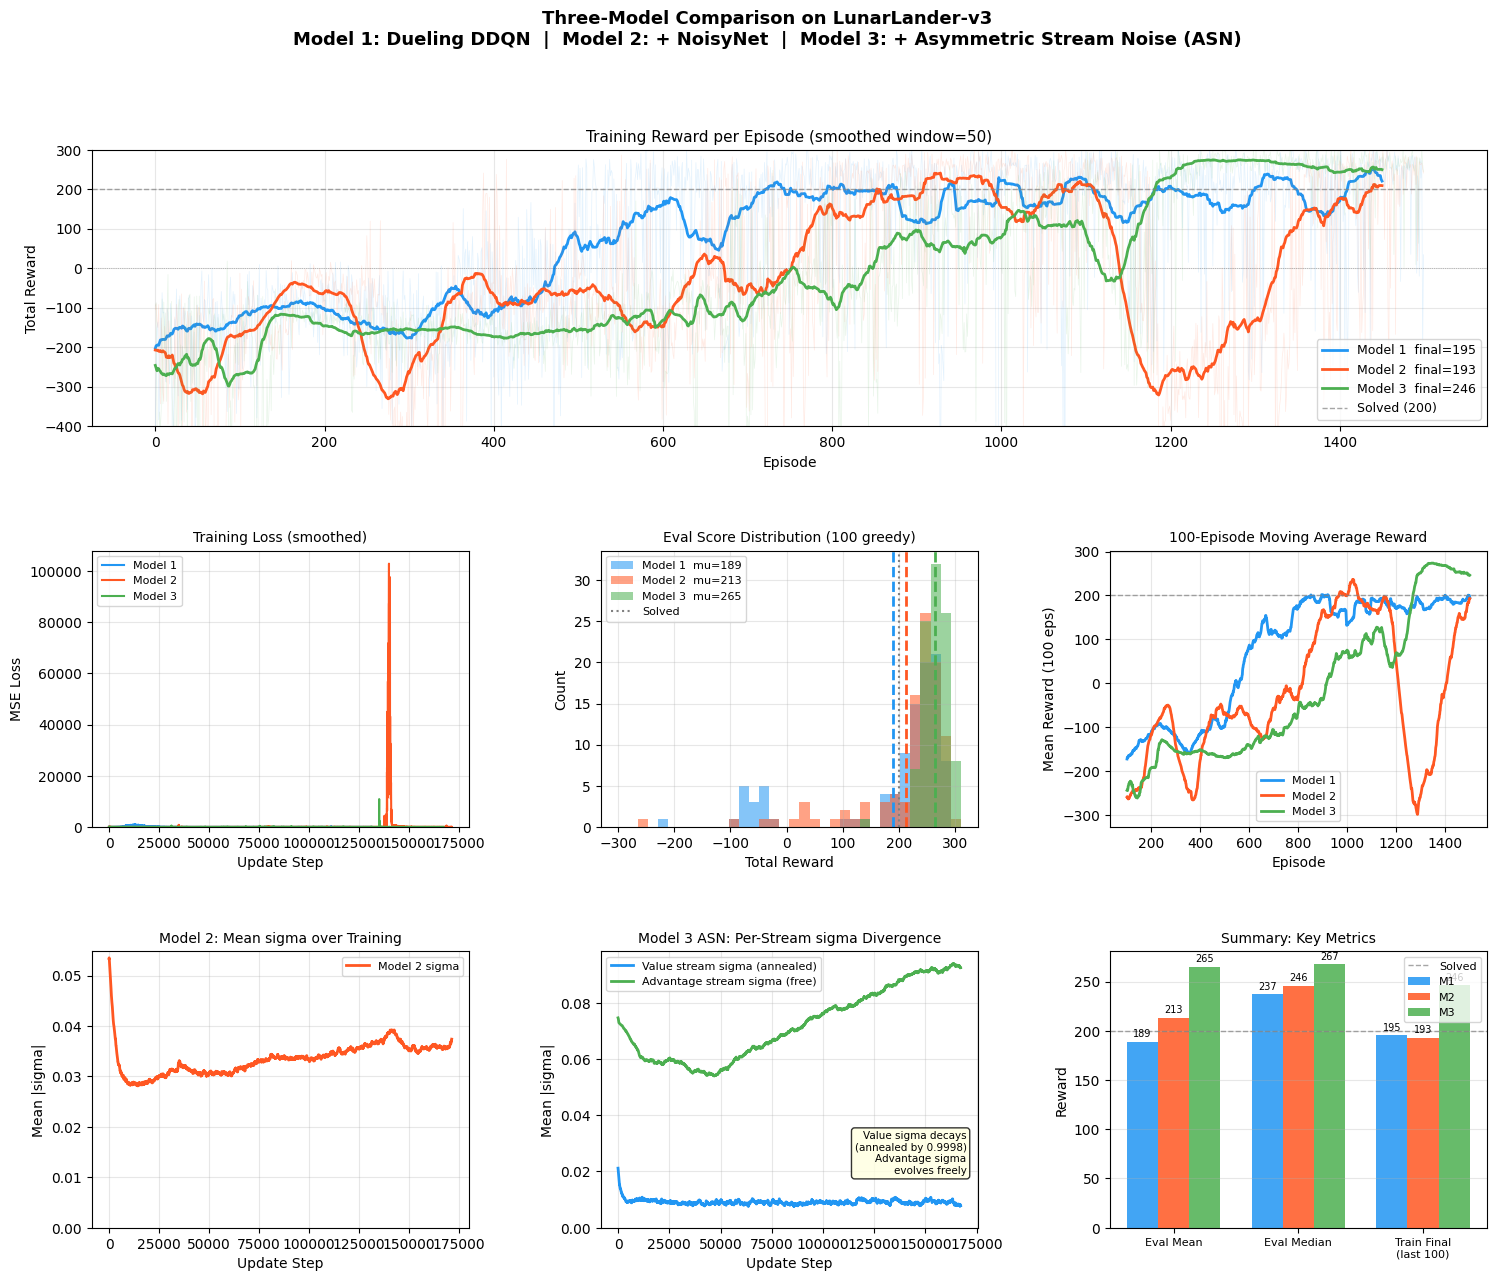

Plot saved to ./lunar_data/three_model_comparison.png


In [21]:
def smooth(v, w=50):
    return np.convolve(v, np.ones(w)/w, mode='valid')

C1, C2, C3 = '#2196F3', '#FF5722', '#4CAF50'   # blue, orange, green
ALPHA_RAW  = 0.12
W          = 50

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

fig.suptitle(
    'Three-Model Comparison on LunarLander-v3\n'
    'Model 1: Dueling DDQN  |  Model 2: + NoisyNet  |  Model 3: + Asymmetric Stream Noise (ASN)',
    fontsize=13, fontweight='bold', y=0.98
)

# ── Row 1: Training Reward ───────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, :])
for r, c, lbl in [
    (rewards1, C1, f'Model 1  final={np.mean(rewards1[-100:]):.0f}'),
    (rewards2, C2, f'Model 2  final={np.mean(rewards2[-100:]):.0f}'),
    (rewards3, C3, f'Model 3  final={np.mean(rewards3[-100:]):.0f}'),
]:
    ax.plot(r, color=c, alpha=ALPHA_RAW, linewidth=0.5)
    ax.plot(np.arange(len(smooth(r, W))), smooth(r, W), color=c, linewidth=2, label=lbl)
ax.axhline(200,  color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Solved (200)')
ax.axhline(0,    color='black', linestyle=':', linewidth=0.5, alpha=0.4)
ax.set_title('Training Reward per Episode (smoothed window=50)', fontsize=11)
ax.set_xlabel('Episode'); ax.set_ylabel('Total Reward')
ax.set_ylim(-400, 300)
ax.legend(fontsize=9, loc='lower right'); ax.grid(True, alpha=0.3)

# ── Row 2 Left: Training Loss ─────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
for log, c, lbl in [
    (agent1.loss_log, C1, 'Model 1'),
    (agent2.loss_log, C2, 'Model 2'),
    (agent3.loss_log, C3, 'Model 3'),
]:
    if len(log) > W:
        ax.plot(smooth(log, W), color=c, linewidth=1.5, label=lbl)
ax.set_title('Training Loss (smoothed)', fontsize=10)
ax.set_xlabel('Update Step'); ax.set_ylabel('MSE Loss')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylim(bottom=0)

# ── Row 2 Middle: Eval Score Distribution ────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
bins = np.linspace(-300, 310, 35)
for scores, c, lbl in [
    (eval1, C1, f'Model 1  mu={np.mean(eval1):.0f}'),
    (eval2, C2, f'Model 2  mu={np.mean(eval2):.0f}'),
    (eval3, C3, f'Model 3  mu={np.mean(eval3):.0f}'),
]:
    ax.hist(scores, bins=bins, color=c, alpha=0.55, label=lbl)
    ax.axvline(np.mean(scores), color=c, linewidth=2, linestyle='--')
ax.axvline(200, color='gray', linewidth=1.5, linestyle=':', label='Solved')
ax.set_title('Eval Score Distribution (100 greedy)', fontsize=10)
ax.set_xlabel('Total Reward'); ax.set_ylabel('Count')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── Row 2 Right: Moving Average Comparison ──────────────────────────────
ax = fig.add_subplot(gs[1, 2])
W2 = 100
for r, c, lbl in [
    (rewards1, C1, 'Model 1'),
    (rewards2, C2, 'Model 2'),
    (rewards3, C3, 'Model 3'),
]:
    if len(r) >= W2:
        ma = [np.mean(r[max(0,i-W2):i]) for i in range(W2, len(r)+1)]
        ax.plot(np.arange(W2, len(r)+1), ma, color=c, linewidth=2, label=lbl)
ax.axhline(200, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.set_title('100-Episode Moving Average Reward', fontsize=10)
ax.set_xlabel('Episode'); ax.set_ylabel('Mean Reward (100 eps)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── Row 3 Left: Model 2 sigma over time ─────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
if agent2.sigma_log and len(agent2.sigma_log) > W:
    ax.plot(agent2.sigma_log, color=C2, alpha=0.2, linewidth=0.5)
    ax.plot(smooth(agent2.sigma_log, W), color=C2, linewidth=2, label='Model 2 sigma')
ax.set_title('Model 2: Mean sigma over Training', fontsize=10)
ax.set_xlabel('Update Step'); ax.set_ylabel('Mean |sigma|')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylim(bottom=0)

# ── Row 3 Middle: Model 3 per-stream sigma ──────────────────────────────
ax = fig.add_subplot(gs[2, 1])
if agent3.sigma_val_log and len(agent3.sigma_val_log) > W:
    ax.plot(agent3.sigma_val_log, color=C1, alpha=0.15, linewidth=0.5)
    ax.plot(agent3.sigma_adv_log, color=C3, alpha=0.15, linewidth=0.5)
    ax.plot(smooth(agent3.sigma_val_log, W), color=C1, linewidth=2, label='Value stream sigma (annealed)')
    ax.plot(smooth(agent3.sigma_adv_log, W), color=C3, linewidth=2, label='Advantage stream sigma (free)')
ax.set_title('Model 3 ASN: Per-Stream sigma Divergence', fontsize=10)
ax.set_xlabel('Update Step'); ax.set_ylabel('Mean |sigma|')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylim(bottom=0)
ax.text(0.97, 0.35,
    'Value sigma decays\n(annealed by 0.9998)\nAdvantage sigma\nevolves freely',
    transform=ax.transAxes, fontsize=7.5, ha='right', va='top',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ── Row 3 Right: Summary Bar Chart ──────────────────────────────────────
ax = fig.add_subplot(gs[2, 2])
metrics = {
    'Eval Mean': [np.mean(eval1), np.mean(eval2), np.mean(eval3)],
    'Eval Median': [np.median(eval1), np.median(eval2), np.median(eval3)],
    'Train Final\n(last 100)': [
        np.mean(rewards1[-100:]),
        np.mean(rewards2[-100:]),
        np.mean(rewards3[-100:])
    ]
}
x     = np.arange(len(metrics))
width = 0.25
for i, (c, lbl) in enumerate([(C1,'M1'), (C2,'M2'), (C3,'M3')]):
    vals = [v[i] for v in metrics.values()]
    bars = ax.bar(x + i*width, vals, width, color=c, alpha=0.85, label=lbl)
    ax.bar_label(bars, fmt='%.0f', padding=2, fontsize=7)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics.keys(), fontsize=8)
ax.axhline(200, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Solved')
ax.set_title('Summary: Key Metrics', fontsize=10)
ax.set_ylabel('Reward')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

plt.savefig('./lunar_data/three_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to ./lunar_data/three_model_comparison.png')

## 10. ASN Stream Divergence Deep-Dive

This plot isolates the key theoretical claim of Model 3:  
the Value and Advantage streams should diverge in their noise levels over training.

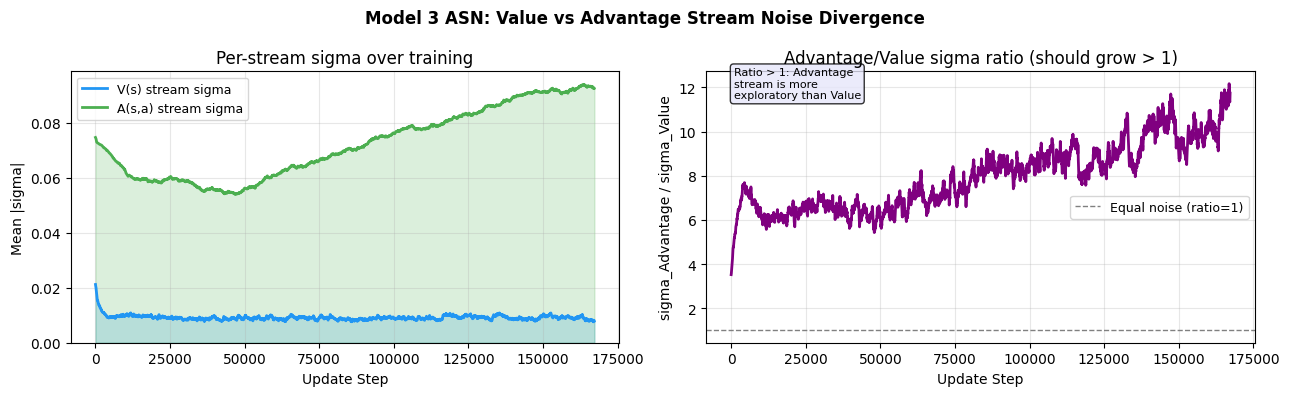

In [19]:
if agent3.sigma_val_log:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('Model 3 ASN: Value vs Advantage Stream Noise Divergence', fontsize=12, fontweight='bold')

    # Left: raw sigma traces
    ax = axes[0]
    steps = np.arange(len(agent3.sigma_val_log))
    ax.fill_between(steps, agent3.sigma_val_log, alpha=0.2, color=C1)
    ax.fill_between(steps, agent3.sigma_adv_log, alpha=0.2, color=C3)
    if len(agent3.sigma_val_log) > W:
        ax.plot(np.arange(len(smooth(agent3.sigma_val_log,W))),
                smooth(agent3.sigma_val_log, W), color=C1, linewidth=2, label='V(s) stream sigma')
        ax.plot(np.arange(len(smooth(agent3.sigma_adv_log,W))),
                smooth(agent3.sigma_adv_log, W), color=C3, linewidth=2, label='A(s,a) stream sigma')
    ax.set_xlabel('Update Step'); ax.set_ylabel('Mean |sigma|')
    ax.set_title('Per-stream sigma over training')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(bottom=0)

    # Right: ratio A_sigma / V_sigma over time
    ax = axes[1]
    ratios = [a/v if v > 1e-8 else 1.0 for a, v in zip(agent3.sigma_adv_log, agent3.sigma_val_log)]
    if len(ratios) > W:
        ax.plot(np.arange(len(smooth(ratios, W))), smooth(ratios, W), color='purple', linewidth=2)
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='Equal noise (ratio=1)')
    ax.set_xlabel('Update Step'); ax.set_ylabel('sigma_Advantage / sigma_Value')
    ax.set_title('Advantage/Value sigma ratio (should grow > 1)')
    ax.text(0.05, 0.9, 'Ratio > 1: Advantage\nstream is more\nexploratory than Value',
            transform=ax.transAxes, fontsize=8, bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.8))
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('./lunar_data/asn_stream_divergence.png', dpi=150, bbox_inches='tight')
    plt.show()

## 11. Save All Results

In [20]:
max_ep = max(len(rewards1), len(rewards2), len(rewards3))

def pad(lst, n):
    return list(lst) + [float('nan')] * (n - len(lst))

df_train = pd.DataFrame({
    'episode':   range(max_ep),
    'model1_reward': pad(rewards1, max_ep),
    'model2_reward': pad(rewards2, max_ep),
    'model3_reward': pad(rewards3, max_ep),
})
df_train.to_csv('./lunar_data/training_rewards.csv', index=False)

df_eval = pd.DataFrame({
    'model1_eval': eval1,
    'model2_eval': eval2,
    'model3_eval': eval3,
})
df_eval.to_csv('./lunar_data/eval_scores.csv', index=False)

# Summary stats
print('\n' + '='*60)
print('FINAL RESULTS SUMMARY')
print('='*60)
print(f'{"Metric":<30} {"Model 1":>10} {"Model 2":>10} {"Model 3":>10}')
print('-'*60)
rows = [
    ('Eval Mean',            np.mean(eval1),             np.mean(eval2),             np.mean(eval3)),
    ('Eval Median',          np.median(eval1),           np.median(eval2),           np.median(eval3)),
    ('Eval Std',             np.std(eval1),              np.std(eval2),              np.std(eval3)),
    ('Eval Max',             max(eval1),                 max(eval2),                 max(eval3)),
    ('Eval % >= 200',        np.mean(np.array(eval1)>=200)*100, np.mean(np.array(eval2)>=200)*100, np.mean(np.array(eval3)>=200)*100),
    ('Train Final 100 mean', np.mean(rewards1[-100:]),   np.mean(rewards2[-100:]),   np.mean(rewards3[-100:])),
]
for name, v1, v2, v3 in rows:
    print(f'{name:<30} {v1:>10.1f} {v2:>10.1f} {v3:>10.1f}')
print('='*60)
print('Files saved to ./lunar_data/')


FINAL RESULTS SUMMARY
Metric                            Model 1    Model 2    Model 3
------------------------------------------------------------
Eval Mean                           188.8      213.4      264.9
Eval Median                         237.3      245.8      267.4
Eval Std                            117.8       90.8       22.8
Eval Max                            289.7      294.3      313.5
Eval % >= 200                        73.0       77.0       99.0
Train Final 100 mean                195.3      193.1      246.3
Files saved to ./lunar_data/


## 12. Discussion & Conclusions

### What to look for in the results

**Training Reward curve**  
- Model 1 (ε-greedy) typically learns fastest initially — aggressive random exploration fills the  
  buffer quickly. But it plateaus once ε decays, especially in LunarLander where late-game  
  precision matters.
- Model 2 (NoisyNet) should overtake Model 1 mid-training as learned noise better focuses  
  exploration on uncertain states.
- Model 3 (ASN) should show the smoothest curve — the advantage normalisation prevents the  
  large negative rewards during crashes from destabilising the value estimates.

**Evaluation distribution**  
- A solved agent (mean ≥ 200) lands safely most of the time. Look at the right tail of the  
  histogram — more episodes near +250 to +300 means the agent found the efficient landing trajectory.

**ASN stream divergence (Model 3 specific)**  
- The Value stream sigma should decay toward near-zero (annealed away).  
- The Advantage stream sigma should grow or stay high — backprop finds it useful for  
  action selection in the complex approach/landing phase.
- The ratio plot should climb above 1 and stay there, confirming the asymmetry is being maintained.

### References
- Wang et al. (2016). *Dueling Network Architectures for Deep Reinforcement Learning.* ICML.
- Fortunato et al. (2017). *Noisy Networks for Exploration.* ICLR 2018.
- van Hasselt et al. (2016). *Learning values across many orders of magnitude (PopArt).* NeurIPS.
- van Hasselt et al. (2015). *Deep Reinforcement Learning with Double Q-Learning.* AAAI.
- Schaul et al. (2016). *Prioritized Experience Replay.* ICLR.
